# Wastewater surveillance, CDC NWSS (Lane A: you prompt, the agent builds)

**SISMID 2026 - Day 2, 9:00.** Drive **Codex / Claude Code / Antigravity CLI**. Each prompt
produces roughly the matching Lane B cell. Not set up? Use Lane B.


## Step 0: point the agent at the task

CDC's National Wastewater Surveillance System has data for influenza? can we download it and plot against ILI percent in Georiga?

> *From CDC's National Wastewater Surveillance System open data on data.cdc.gov (the*
> *'Wastewater Data for Influenza A' dataset, Socrata id `ymmh-divb`), write*
> *`nwss_fetch(state)` that returns a tidy DataFrame for one state, and a `load_cache()`*
> *reading `data/cdc_nwss_influenza_a_ga_cached.csv`. Add `get_ga_flu_wastewater()` that*
> *pulls Georgia, parses the collection date, coerces `pcr_target_avg_conc` to numeric,*
> *and falls back to the cache.*


In [1]:
# Paste the agent's helper functions here and run them.
import urllib.request, urllib.parse, json, os
import pandas as pd, matplotlib.pyplot as plt

# CDC NWSS 'Wastewater Data for Influenza A' (Socrata dataset ymmh-divb)
NWSS_ID = "ymmh-divb"
COLS = ["sample_collect_date", "site", "counties_served", "population_served",
        "pcr_target_avg_conc", "pcr_target_flowpop_lin", "pcr_target_detect"]
CACHE_PATHS = ["../data/cdc_nwss_influenza_a_ga_cached.csv",
               "data/cdc_nwss_influenza_a_ga_cached.csv",
               "./cdc_nwss_influenza_a_ga_cached.csv"]


def nwss_fetch(state="ga"):
    """Influenza A wastewater samples for one state from CDC NWSS. DataFrame or None."""
    params = {"state_territory": state, "$select": ",".join(COLS),
              "$order": "sample_collect_date", "$limit": "50000"}
    url = f"https://data.cdc.gov/resource/{NWSS_ID}.json?" + urllib.parse.urlencode(params)
    try:
        rows = json.loads(urllib.request.urlopen(url, timeout=45).read())
        return pd.DataFrame(rows)
    except Exception as e:
        print(f"CDC NWSS live pull failed ({type(e).__name__}): {e}")
        return None


def load_cache():
    for p in CACHE_PATHS:
        if os.path.exists(p):
            print(f"Using cached snapshot: {p}")
            return pd.read_csv(p)
    raise FileNotFoundError("NWSS cache not found; check the data/ folder.")


def get_ga_flu_wastewater():
    """Georgia influenza A wastewater samples, tidy: parsed date + numeric concentration."""
    df = nwss_fetch("ga")
    if df is None or df.empty:
        df = load_cache()
    df["date"] = pd.to_datetime(df["sample_collect_date"])
    df["conc"] = pd.to_numeric(df["pcr_target_avg_conc"], errors="coerce")
    return df


## Step 1: pull Georgia flu-A wastewater

> *Use get_ga_flu_wastewater(); print the row count, date range, and number of distinct*
> *sites, and show a few rows with the counties and population served.*


In [2]:
# Agent's fetch:
ww = get_ga_flu_wastewater()
print("rows:", len(ww), "| range:", ww["date"].min().date(), "to", ww["date"].max().date())
print("distinct sites:", ww["site"].nunique())
ww[["date", "site", "counties_served", "population_served", "conc"]].head()


rows: 7093 | range: 2022-06-26 to 2026-07-13
distinct sites: 27


,date,site,counties_served,population_served,conc
0,2022-06-26,337,Fulton,189593,0.00000
1,2022-06-26,336,Fulton,84486,0.00000
2,2022-06-26,338,Fulton,190000,0.00000
3,2022-06-27,326,Fulton,12818,1783.59406
4,2022-06-28,336,Fulton,84486,4213.35639


## Step 2: aggregate to a weekly state signal

> *A single site is noisy. Aggregate to a weekly mean concentration across all Georgia*
> *sites and plot it.*

**Your check:** does the winter flu season show up?


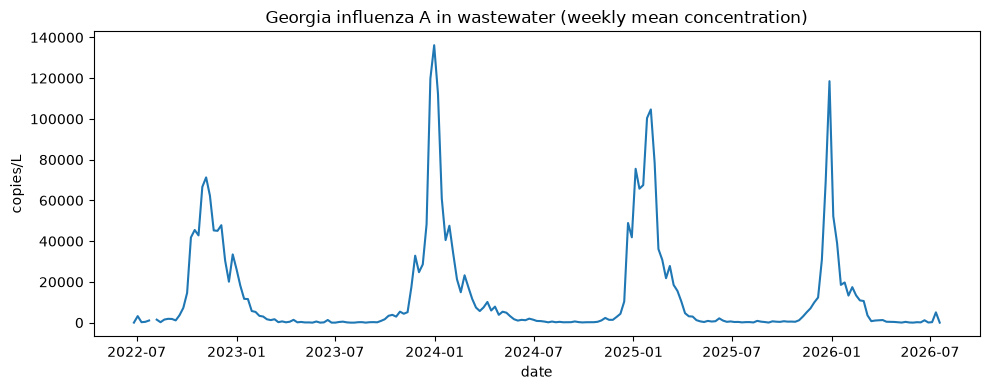

In [3]:
# Agent's weekly aggregate + plot:
wk = (ww.dropna(subset=["conc"])
        .set_index("date").groupby(pd.Grouper(freq="W"))["conc"].mean().reset_index())
plt.figure(figsize=(10, 4))
plt.plot(wk["date"], wk["conc"])
plt.title("Georgia influenza A in wastewater (weekly mean concentration)")
plt.ylabel("copies/L")
plt.xlabel("date")
plt.tight_layout()
plt.savefig("../ga_flu_wastewater_weekly.png", dpi=150)
plt.show()


## Step 3: single site vs aggregate

> *Overlay the single largest-population site against the state weekly mean, so I can see*
> *why aggregation matters.*


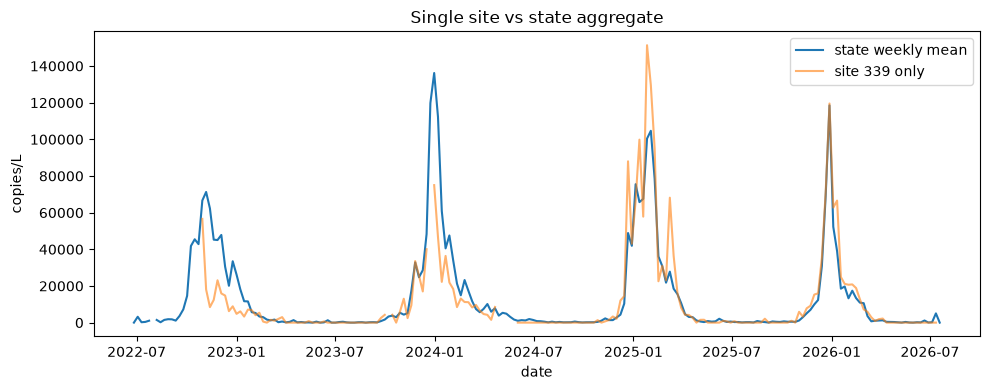

In [4]:
# Agent's site-vs-aggregate plot:
ww["pop"] = pd.to_numeric(ww["population_served"], errors="coerce")
big = ww.sort_values("pop", ascending=False)["site"].iloc[0]
site = (ww[ww["site"] == big].dropna(subset=["conc"])
          .set_index("date").groupby(pd.Grouper(freq="W"))["conc"].mean().reset_index())
plt.figure(figsize=(10, 4))
plt.plot(wk["date"], wk["conc"], label="state weekly mean")
plt.plot(site["date"], site["conc"], alpha=0.6, label=f"site {big} only")
plt.legend()
plt.title("Single site vs state aggregate")
plt.ylabel("copies/L")
plt.xlabel("date")
plt.tight_layout()
plt.savefig("../ga_flu_wastewater_site_vs_aggregate.png", dpi=150)
plt.show()


## Step 4: sanity-check and save

> *Report how many sites reported per week recently and the latest sample date (to show*
> *the reporting lag), then save the weekly series to `ga_flu_wastewater_weekly.csv`.*


In [5]:
# Agent's sanity-check + save:
cov = ww.dropna(subset=["conc"]).set_index("date").groupby(pd.Grouper(freq="W"))["site"].nunique()
print("reporting sites per week (last 6):")
print(cov.tail(6))
print("\nlatest sample date:", ww["date"].max().date(), "(expect a lag vs today)")

wk.to_csv("../ga_flu_wastewater_weekly.csv", index=False)
print("saved ga_flu_wastewater_weekly.csv", wk.shape)


reporting sites per week (last 6):
date
2026-06-14    21
2026-06-21    19
2026-06-28    18
2026-07-05    15
2026-07-12     8
2026-07-19     1
Freq: W-SUN, Name: site, dtype: int64

latest sample date: 2026-07-13 (expect a lag vs today)
saved ga_flu_wastewater_weekly.csv (213, 2)


## Stretch: overlay against ILI percent (CDC FluView, Georgia)

> *Pull Georgia's ILINet weighted-ILI percent (CDC FluView, mirrored by the Delphi Epidata*
> *API, no key needed) for the same period, align it to the wastewater weekly series by*
> *epiweek, and plot both on a dual-axis chart. Report the correlation and check whether*
> *wastewater leads ILI.*


ILI rows: 212 | range: 2022-06-26 to 2026-07-12
correlation (same week): 0.86
correlation of wastewater(t-lag) vs ILI(t), by lag (weeks): {0: np.float64(0.86), 1: np.float64(0.85), 2: np.float64(0.73), 3: np.float64(0.62), 4: np.float64(0.53), 5: np.float64(0.44)}
-> no lead: same-week alignment is best


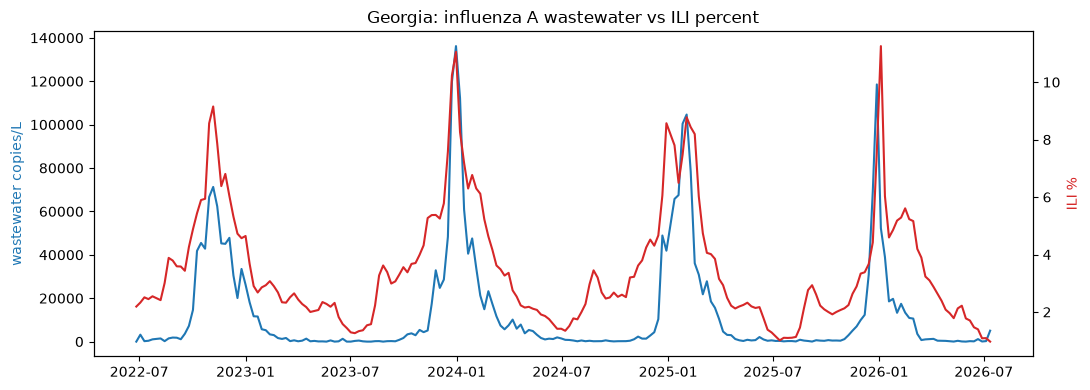

In [6]:
# Agent's ILI pull + overlay:
ILI_CACHE_PATHS = ["../data/cdc_ili_ga_cached.csv",
                    "data/cdc_ili_ga_cached.csv",
                    "./cdc_ili_ga_cached.csv"]


def ili_fetch(region="ga", start_epiweek=None, end_epiweek=None):
    """Weekly ILINet percent for one region, from CDC FluView (Delphi Epidata mirror,
    no key). DataFrame(epiweek, date, ili, wili) or None."""
    if start_epiweek is None:
        start_epiweek = int(ww["date"].min().strftime("%Y%V"))
    if end_epiweek is None:
        end_epiweek = int(pd.Timestamp.today().strftime("%Y%V"))
    params = {"regions": region, "epiweeks": f"{start_epiweek}-{end_epiweek}"}
    url = "https://api.delphi.cmu.edu/epidata/fluview/?" + urllib.parse.urlencode(params)
    try:
        data = json.loads(urllib.request.urlopen(url, timeout=30).read())
        rows = data.get("epidata") or []
        if not rows:
            raise RuntimeError(f"empty response: {data.get('message')}")
        df = pd.DataFrame(rows)[["epiweek", "wili", "ili"]]
        # epiweek -> the Sunday date that ends that MMWR week, to align with wastewater
        df["date"] = pd.to_datetime(df["epiweek"].astype(str) + "0", format="%Y%W%w")
        return df.sort_values("date").reset_index(drop=True)
    except Exception as e:
        print(f"CDC FluView (Delphi) live pull failed ({type(e).__name__}): {e}")
        return None


def load_ili_cache():
    for p in ILI_CACHE_PATHS:
        if os.path.exists(p):
            print(f"Using cached snapshot: {p}")
            return pd.read_csv(p, parse_dates=["date"])
    raise FileNotFoundError("ILI cache not found; check the data/ folder.")


def get_ga_ili():
    df = ili_fetch("ga")
    if df is None or df.empty:
        df = load_ili_cache()
    return df


ili = get_ga_ili()
print("ILI rows:", len(ili), "| range:", ili["date"].min().date(), "to", ili["date"].max().date())

merged = pd.merge_asof(wk.sort_values("date"), ili.sort_values("date"),
                        on="date", direction="nearest", tolerance=pd.Timedelta("4D")).dropna()
corr = merged["conc"].corr(merged["wili"])
lead_corrs = {lag: merged["conc"].shift(lag).corr(merged["wili"])
              for lag in range(0, 6)}
best_lead = max(lead_corrs, key=lead_corrs.get)
print(f"correlation (same week): {corr:.2f}")
print("correlation of wastewater(t-lag) vs ILI(t), by lag (weeks):", {k: round(v, 2) for k, v in lead_corrs.items()})
print(f"-> best alignment at wastewater leading ILI by {best_lead} week(s)"
      if best_lead > 0 else "-> no lead: same-week alignment is best")

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(merged["date"], merged["conc"], color="tab:blue", label="wastewater (copies/L)")
ax1.set_ylabel("wastewater copies/L", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["wili"], color="tab:red", label="ILI % (weighted)")
ax2.set_ylabel("ILI %", color="tab:red")
plt.title("Georgia: influenza A wastewater vs ILI percent")
fig.tight_layout()
plt.savefig("../ga_flu_wastewater_vs_ili.png", dpi=150)
plt.show()


## Reflection

- You described the outcome; the agent handled the messy CDC schema.
- Wastewater is biology, not behavior - a stream that fails differently from search.
- On your own: overlay against ILI and judge the lead time.
